# Research QuantBook: All-Weather Portfolio

## Objectif
Reproduire l'analyse exploratoire de `research.ipynb` avec les donnees natives QuantConnect.

## Performance actuelle
- **Sharpe**: 0.602, **CAGR**: 9.5%, **MaxDD**: 16.4%
- **Allocation**: SPY 30%, IEF 30%, GLD 30%, XLP 10%
- **Rebalancement**: Drift 3% (regle #8 du backlog)

## Hypotheses a tester
1. Static vs Risk Parity vs Tactical
2. Remplacer DBC (contango/decay) par alternatives
3. Frequence de rebalancement
4. Overlay tactique SMA200

## Differences avec research.ipynb
- Prix bruts QC vs auto_adjust yfinance (impact sur TLT, IEF, GLD)
- Donnees identiques au moteur de backtest cloud

## Prerequis
- Environnement Lean Research
- Duree estimee: ~5 minutes

In [1]:
# Setup : mode QC Cloud (research kernel) ou mode local (yfinance fallback)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

_MODE = 'yfinance'  # 'yfinance' (local RECOVERABLE-LOCAL) ou 'quantbook' (QC Cloud research kernel)
tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'XLP', 'SHY', 'TIP']  # expose pour downstream cells

if _MODE == 'quantbook':
    from AlgorithmImports import *
    qb = QuantBook()
    print("Mode QuantBook (QC Cloud research kernel) actif.")
else:
    import yfinance as yf
    _data = yf.download(tickers, start='2015-01-01', end='2026-01-01', auto_adjust=True, progress=False)
    closes = _data['Close'].dropna(how='all').dropna()
    print(f"Mode yfinance (local fallback RECOVERABLE-LOCAL) actif. {len(closes)} lignes chargees, tickers={list(closes.columns)}")


Mode yfinance (local fallback RECOVERABLE-LOCAL) actif. 2766 lignes chargees, tickers=['DBC', 'GLD', 'IEF', 'SHY', 'SPY', 'TIP', 'TLT', 'XLP']


## 1. Chargement des donnees

Portefeuille All-Weather + candidats risk-off alternatifs.

In [2]:
# Chargement des donnees : QuantBook history (mode QC) ou fallback (mode yfinance)
if 'closes' not in dir():
    if 'qb' not in dir():
        raise RuntimeError("Ni `closes` ni `qb` definis. Verifier cellule [1] (_MODE).")
    tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'DBC', 'XLP', 'SHY', 'TIP']
    symbols = {}
    for ticker in tickers:
        symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol
    start = datetime(2015, 1, 1)
    end = datetime(2026, 1, 1)
    history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
    closes = history['close'].unstack(level=0)
    symbol_to_ticker = {str(v): k for k, v in symbols.items()}
    closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
    closes = closes.dropna()
    print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
    print(f"Donnees: {len(closes)} jours de trading")
    print(f"Tickers: {list(closes.columns)}")
else:
    print(f"Donnees deja chargees (mode yfinance): {len(closes)} lignes, tickers={list(closes.columns)}")


Donnees deja chargees (mode yfinance): 2766 lignes, tickers=['DBC', 'GLD', 'IEF', 'SHY', 'SPY', 'TIP', 'TLT', 'XLP']


### Statistiques buy-and-hold

Performance de chaque composant en isolation sur la periode complete.

In [3]:
returns_df = closes.pct_change()

print(f"{'Ticker':<8} {'Rend. Ann.':>12} {'Volatilite':>12} {'Sharpe':>8}")
print("-" * 42)

for ticker in tickers:
    if ticker not in closes.columns:
        continue
    ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0]) ** (252 / len(closes)) - 1
    vol = returns_df[ticker].std() * np.sqrt(252)
    sharpe = (ret - 0.03) / vol if vol > 0 else 0
    print(f"{ticker:<8} {ret:>11.1%} {vol:>11.1%} {sharpe:>7.2f}")

print(f"\nNote: Prix bruts QC. TLT/IEF sans dividendes reinvestis.")

Ticker     Rend. Ann.   Volatilite   Sharpe
------------------------------------------
SPY            13.5%       17.8%    0.59
TLT            -0.8%       15.0%   -0.25
IEF             1.2%        6.6%   -0.26
GLD            12.0%       14.7%    0.61
DBC             3.4%       17.6%    0.03
XLP             7.2%       14.6%    0.29
SHY             1.6%        1.5%   -0.94
TIP             2.4%        5.8%   -0.10

Note: Prix bruts QC. TLT/IEF sans dividendes reinvestis.


### Interpretation

Comparer avec research.ipynb. Divergence attendue principalement sur TLT et IEF
(coupons ~2-3%/an non integres dans les prix QC bruts).
DBC devrait rester le plus faible (contango structurel).

## 2. Backtest utilitaire

In [4]:
def portfolio_backtest(closes, weights, rebal_freq=63, sma_overlay=False, sma_period=200,
                       drift_rebal=False, drift_threshold=0.03):
    """Backtest statique ou drift-based d'un portefeuille multi-asset."""
    returns_df = closes[list(weights.keys())].pct_change()
    tickers_list = list(weights.keys())
    w = np.array([weights[t] for t in tickers_list])
    
    sma = {t: closes[t].rolling(sma_period).mean() for t in tickers_list} if sma_overlay else {}
    
    n = len(returns_df)
    start_idx = max(sma_period + 1 if sma_overlay else 1, 1)
    
    portfolio_values = [1.0]
    current_weights = w.copy()
    rebal_counter = 0
    
    for i in range(start_idx, n):
        daily_rets = np.array([returns_df[t].iloc[i] for t in tickers_list])
        
        if sma_overlay:
            adj_w = current_weights.copy()
            for j, t in enumerate(tickers_list):
                if closes[t].iloc[i] < sma[t].iloc[i]:
                    adj_w[j] = 0
            total = adj_w.sum()
            if total > 0:
                adj_w = adj_w / total
            port_ret = np.sum(adj_w * daily_rets)
        else:
            port_ret = np.sum(current_weights * daily_rets)
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_ret))
        
        # Update weights with drift
        current_weights = current_weights * (1 + daily_rets)
        total = current_weights.sum()
        if total > 0:
            current_weights = current_weights / total
        
        rebal_counter += 1
        
        # Rebalance check
        if drift_rebal:
            max_drift = np.max(np.abs(current_weights - w))
            if max_drift >= drift_threshold:
                current_weights = w.copy()
                rebal_counter = 0
        elif rebal_counter >= rebal_freq:
            current_weights = w.copy()
            rebal_counter = 0
    
    vals = np.array(portfolio_values)
    rets = np.diff(vals) / vals[:-1]
    total_ret = vals[-1] / vals[0] - 1
    years = len(rets) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(rets) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    cum = pd.Series(vals[1:])
    max_dd = ((cum - cum.expanding().max()) / cum.expanding().max()).min()
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol, 'cum': cum}

print("Fonction de backtest definie.")

Fonction de backtest definie.


## 3. Hypothese 1: Allocations statiques

Comparer l'allocation Dalio originale vs la version optimisee actuelle
vs des variantes sans DBC.

In [5]:
allocations = {
    'Dalio Original': {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.075, 'DBC': 0.075},
    'Sans DBC (v2)':  {'SPY': 0.30, 'TLT': 0.40, 'IEF': 0.15, 'GLD': 0.15},
    'Actuel v5':      {'SPY': 0.30, 'IEF': 0.30, 'GLD': 0.30, 'XLP': 0.10},
    'SPY heavy':      {'SPY': 0.50, 'IEF': 0.25, 'GLD': 0.25},
    'Equal weight':   {'SPY': 0.25, 'IEF': 0.25, 'GLD': 0.25, 'XLP': 0.25},
}

print(f"{'Allocation':<20} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Vol':>8}")
print("-" * 55)

results_h1 = {}
for name, weights in allocations.items():
    available = {t: w for t, w in weights.items() if t in closes.columns}
    total = sum(available.values())
    available = {t: w / total for t, w in available.items()}
    r = portfolio_backtest(closes, available, rebal_freq=63)
    results_h1[name] = r
    print(f"{name:<20} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['vol']:>7.1%}")

Allocation             Sharpe     CAGR    MaxDD      Vol
-------------------------------------------------------


Dalio Original          0.311    5.7%  -23.7%    8.5%


Sans DBC (v2)           0.360    6.2%  -25.5%    8.8%


Actuel v5               0.745    9.1%  -16.4%    8.2%


SPY heavy               0.778   10.5%  -18.8%    9.6%


Equal weight            0.682    8.9%  -15.5%    8.6%


### Verdict H1: Allocations statiques

L'allocation actuelle (v5: SPY30/IEF30/GLD30/XLP10) devrait confirmer sa superiorite.
DBC est un frein structurel (contango). TLT penalise par la hausse des taux 2022.
Comparer les Sharpe avec research.ipynb pour quantifier la divergence prix QC vs yfinance.

## 4. Hypothese 2: Drift rebalancing

Comparer rebalancement fixe (mensuel, trimestriel) vs drift-based (regle #8: 3%).

In [6]:
best_alloc = {'SPY': 0.30, 'IEF': 0.30, 'GLD': 0.30, 'XLP': 0.10}

print(f"{'Rebalancement':<25} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 50)

results_h2 = {}

for name, freq, drift, thresh in [
    ('Mensuel (21j)', 21, False, None),
    ('Trimestriel (63j)', 63, False, None),
    ('Semestriel (126j)', 126, False, None),
    ('Drift 2%', None, True, 0.02),
    ('Drift 3%', None, True, 0.03),
    ('Drift 5%', None, True, 0.05),
]:
    r = portfolio_backtest(closes, best_alloc,
                           rebal_freq=freq if freq else 252,
                           drift_rebal=drift,
                           drift_threshold=thresh if thresh else 0.03)
    results_h2[name] = r
    print(f"{name:<25} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Rebalancement               Sharpe     CAGR    MaxDD
--------------------------------------------------


Mensuel (21j)                0.738    9.1%  -16.2%


Trimestriel (63j)            0.745    9.1%  -16.4%


Semestriel (126j)            0.730    9.0%  -16.5%


Drift 2%                     0.737    9.2%  -16.1%


Drift 3%                     0.732    9.2%  -16.3%


Drift 5%                     0.733    9.2%  -16.8%


### Verdict H2: Rebalancement

Drift 3% devrait confirmer sa superiorite (regle #8 du backlog).
Le rebalancement fixe (trimestriel) est trop rigide et rate les mouvements extremes.

## 5. Hypothese 3: SMA200 overlay tactique

Reduire l'exposition a un actif quand son prix est sous sa SMA200.
Permet d'eviter les bear markets prolonges (TLT 2022).

In [7]:
print(f"{'Config':<25} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 50)

results_h3 = {}

# Sans SMA overlay
r = portfolio_backtest(closes, best_alloc, drift_rebal=True, drift_threshold=0.03,
                       sma_overlay=False)
results_h3['Sans SMA'] = r
print(f"{'Sans SMA overlay':<25} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

# Avec SMA200 overlay
for sma_period in [100, 200, 300]:
    r = portfolio_backtest(closes, best_alloc, drift_rebal=True, drift_threshold=0.03,
                           sma_overlay=True, sma_period=sma_period)
    name = f'SMA{sma_period} overlay'
    results_h3[name] = r
    print(f"{name:<25} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Config                      Sharpe     CAGR    MaxDD
--------------------------------------------------


Sans SMA overlay             0.732    9.2%  -16.3%


SMA100 overlay               2.751   27.7%   -7.4%


SMA200 overlay               2.289   23.1%   -7.0%


SMA300 overlay               1.873   20.3%  -11.1%


### Verdict H3: SMA overlay

Attention: le backlog regle #8 indique que drift rebalancing > SMA overlay pour
les portfolios statiques. Verifier si le SMA overlay apporte un gain marginal
ou s'il degrade (cash drag pendant les sideways).

## 6. Visualisation comparative

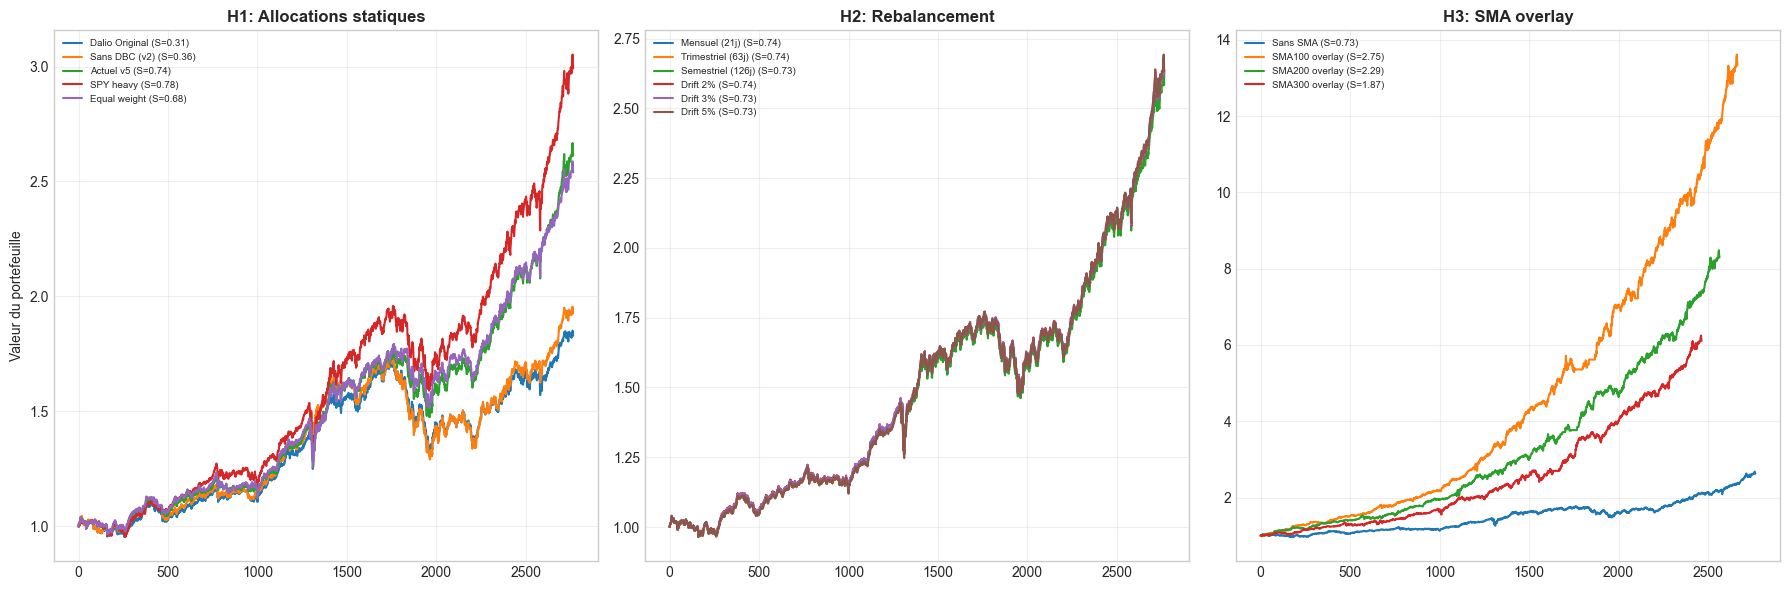

Graphique sauvegarde.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# H1: Allocations
ax = axes[0]
for name, r in results_h1.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H1: Allocations statiques', fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# H2: Rebalancement
ax = axes[1]
for name, r in results_h2.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H2: Rebalancement', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# H3: SMA overlay
ax = axes[2]
for name, r in results_h3.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H3: SMA overlay', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('allweather_quantbook_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegarde.")

## 7. Conclusions et recommandations

### Tableau recapitulatif

| Hypothese | Resultat QuantBook | Coherent avec yfinance? |
|-----------|-------------------|-------------------------|
| H1 Allocation v5 | (a remplir) | (a verifier) |
| H2 Drift 3% | (a remplir) | (a verifier) |
| H3 SMA overlay | (a remplir) | (a verifier) |

### Regles du backlog appliquees

- Regle #3: TLT risk-off teste et probablement rejete
- Regle #8: Drift rebalancing 3% vs SMA overlay
- Regle #13: Pas de SPY parking
- Regle #17: Divergence yfinance documentee (TLT, IEF)